In [6]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

In [7]:
# 1 Load Data
df = pd.read_csv("../co2.csv")


In [ ]:
# 2 Select Features (X) and Target (y)
X = df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 
        'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 
        'Fuel Consumption Comb (mpg)']].values

y = df[['CO2 Emissions(g/km)']].values


(7385, 6)
(7385, 1)


In [9]:
# 3 Mean Normalization
x_min = X.min(axis=0)
x_max = X.max(axis=0)

mean_normalized = (X - x_min) / (x_max - x_min)


In [10]:
# 4 Add Bias Term
ones = np.ones((mean_normalized.shape[0], 1))
X_b = np.hstack((ones, mean_normalized))


In [11]:
# 5 Compute Theta using Normal Equation: θ = (Xᵗ X)⁻¹ Xᵗ y
X_transpose = X_b.T
theta = np.linalg.inv(X_transpose.dot(X_b)).dot(X_transpose).dot(y)

In [12]:
# 6 Predictions
y_hat = X_b.dot(theta)


In [13]:
# 7 Mean Squared Error (MSE)
n = len(y)
mse = ((y - y_hat) ** 2).sum() / n
print("Theta:", theta)
print("MSE:", mse)

Theta: [[ 242.06622157]
 [  37.45202847]
 [  98.00088936]
 [  -0.62788573]
 [  74.54418638]
 [  36.80702155]
 [-198.56256006]]
MSE: 328.95368292634635


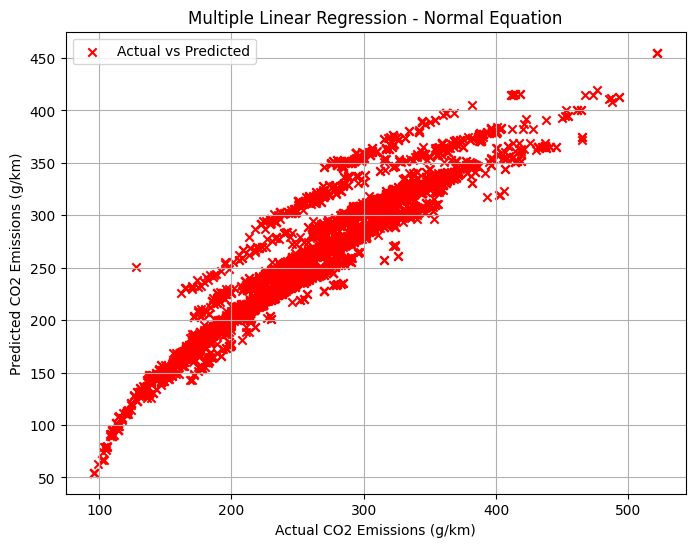

In [14]:
# 8 Plot Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y, y_hat, label="Actual vs Predicted", marker="x", color="red")
plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Multiple Linear Regression - Normal Equation")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# 9 Predict for New Car
new_car = np.array([[2.0, 4, 10.0, 8.0, 9.0, 30]])  # Example new data
new_car_norm = (new_car - x_min) / (x_max - x_min)
new_car_b = np.hstack(([1], new_car_norm[0]))
new_prediction = new_car_b.dot(theta)
print("Prediction for new car:", new_prediction)

Prediction for new car: [216.07379729]
